Pada tahap ini, dataset diunduh langsung dari Kaggle menggunakan kagglehub. Dataset yang digunakan adalah Web Page Phishing Detection Dataset, yaitu dataset untuk mendeteksi website phishing berdasarkan fitur URL.

In [38]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shashwatwork/web-page-phishing-detection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'web-page-phishing-detection-dataset' dataset.
Path to dataset files: /kaggle/input/web-page-phishing-detection-dataset


Pada tahap ini, library yang diperlukan diimpor. Library digunakan untuk mengolah data, membuat visualisasi, membagi data, membangun model, mengevaluasi model, dan menyimpan model.

In [39]:
# Library dasar
import pandas as pd
import numpy as np

# Visualisasi data
import matplotlib.pyplot as plt

# Split data
from sklearn.model_selection import train_test_split

# Model machine learning
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Evaluasi model
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Menyimpan model
import pickle

# Menghilangkan warning agar output lebih rapi
import warnings
warnings.filterwarnings('ignore')

Pada tahap ini, file CSV dari dataset dibaca ke dalam dataframe. Dataframe digunakan agar data dapat ditampilkan, diperiksa, dan diolah menggunakan Python.

In [40]:
import os

# Mencari file CSV di folder dataset
csv_file = None

for file in os.listdir(path):
    if file.endswith(".csv"):
        csv_file = file
        break

# Membaca file CSV
df = pd.read_csv(os.path.join(path, csv_file))

# Menampilkan nama file dan 5 data pertama
print("File yang digunakan:", csv_file)
df.head()

File yang digunakan: dataset_phishing.csv


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


Pada tahap ini, data diperiksa untuk mengetahui jumlah baris, jumlah kolom, tipe data, dan distribusi kelas target. Pemeriksaan ini penting agar struktur dataset lebih mudah dipahami sebelum masuk ke tahap preprocessing.

In [41]:

# Melihat jumlah baris dan kolom
print("Jumlah baris dan kolom:", df.shape)

# Melihat nama seluruh kolom
print("\nNama kolom:")
print(df.columns.tolist())

# Melihat tipe data setiap kolom
print("\nTipe data:")
print(df.dtypes)

# Melihat jumlah data pada target
print("\nDistribusi target:")
print(df['status'].value_counts())

Jumlah baris dan kolom: (11430, 89)

Nama kolom:
['url', 'length_url', 'length_hostname', 'ip', 'nb_dots', 'nb_hyphens', 'nb_at', 'nb_qm', 'nb_and', 'nb_or', 'nb_eq', 'nb_underscore', 'nb_tilde', 'nb_percent', 'nb_slash', 'nb_star', 'nb_colon', 'nb_comma', 'nb_semicolumn', 'nb_dollar', 'nb_space', 'nb_www', 'nb_com', 'nb_dslash', 'http_in_path', 'https_token', 'ratio_digits_url', 'ratio_digits_host', 'punycode', 'port', 'tld_in_path', 'tld_in_subdomain', 'abnormal_subdomain', 'nb_subdomains', 'prefix_suffix', 'random_domain', 'shortening_service', 'path_extension', 'nb_redirection', 'nb_external_redirection', 'length_words_raw', 'char_repeat', 'shortest_words_raw', 'shortest_word_host', 'shortest_word_path', 'longest_words_raw', 'longest_word_host', 'longest_word_path', 'avg_words_raw', 'avg_word_host', 'avg_word_path', 'phish_hints', 'domain_in_brand', 'brand_in_subdomain', 'brand_in_path', 'suspecious_tld', 'statistical_report', 'nb_hyperlinks', 'ratio_intHyperlinks', 'ratio_extHyper

Pada tahap ini, data diperiksa untuk melihat apakah terdapat missing value dan data duplikat. Pemeriksaan ini penting karena data yang kosong atau berulang dapat memengaruhi hasil pelatihan model.

In [42]:
# Mengecek jumlah missing value pada setiap kolom
missing_values = df.isnull().sum()

print("Jumlah missing value:")
print(missing_values[missing_values > 0])

# Mengecek jumlah data duplikat
duplicate_count = df.duplicated().sum()

print("\nJumlah data duplikat:", duplicate_count)

Jumlah missing value:
Series([], dtype: int64)

Jumlah data duplikat: 0


Pada tahap ini, distribusi kelas target divisualisasikan untuk melihat perbandingan jumlah website legitimate dan phishing. Distribusi target penting diperiksa agar model tidak bias terhadap salah satu kelas.

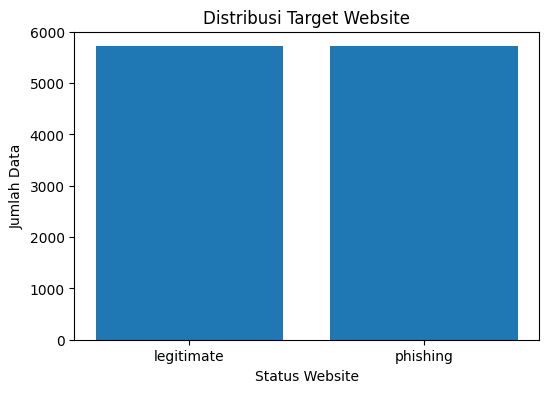

status
legitimate    5715
phishing      5715
Name: count, dtype: int64


In [43]:
target_counts = df["status"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(target_counts.index, target_counts.values)
plt.title("Distribusi Target Website")
plt.xlabel("Status Website")
plt.ylabel("Jumlah Data")
plt.show()

print(target_counts)

Pada tahap ini, label target diubah menjadi bentuk numerik agar dapat diproses oleh model machine learning. Label legitimate diberi nilai 0, sedangkan phishing diberi nilai 1.

In [44]:
df["status_encoded"] = df["status"].map({
    "legitimate": 0,
    "phishing": 1
})

df[["status", "status_encoded"]].head()

,status,status_encoded
0,legitimate,0
1,phishing,1
2,phishing,1
3,legitimate,0
4,legitimate,0


Pada tahap ini, fitur dan target dipisahkan. Kolom url tidak digunakan karena berbentuk teks mentah, sedangkan kolom status asli tidak digunakan karena sudah diganti menjadi status_encoded.

In [45]:
X = df.drop(columns=["url", "status", "status_encoded"])
y = df["status_encoded"]

print("Jumlah fitur:", X.shape[1])
print("Jumlah data:", X.shape[0])
print("Nama target:", y.name)

Jumlah fitur: 87
Jumlah data: 11430
Nama target: status_encoded


Data dibagi menjadi data training dan data testing. Data training digunakan untuk melatih model, sedangkan data testing digunakan untuk menguji kemampuan model dalam mengenali data baru.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])

Jumlah data training: 9144
Jumlah data testing: 2286


Model Decision Tree dilatih menggunakan data training. Model ini dipilih karena sesuai dengan materi yang sudah dipelajari di kelas dan cocok untuk masalah klasifikasi phishing website.

In [47]:
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

decision_tree.fit(X_train, y_train)

print("Model Decision Tree berhasil dilatih.")

Model Decision Tree berhasil dilatih.


Model yang sudah dilatih digunakan untuk memprediksi data testing. Hasil prediksi kemudian dibandingkan dengan label asli untuk melihat performa model.

In [48]:
y_pred_dt = decision_tree.predict(X_test)

print("Hasil prediksi Decision Tree:")
print(y_pred_dt[:10])

print("\nLabel asli:")
print(y_test.values[:10])

Hasil prediksi Decision Tree:
[1 1 1 1 0 0 0 1 0 1]

Label asli:
[1 1 1 1 0 0 0 1 0 1]


Evaluasi dilakukan untuk mengetahui kemampuan Decision Tree dalam membedakan website phishing dan legitimate. Metrik yang digunakan adalah accuracy, precision, recall, dan F1 score.

In [49]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("Evaluasi Model Decision Tree")
print("Accuracy :", round(accuracy_dt, 4))
print("Precision:", round(precision_dt, 4))
print("Recall   :", round(recall_dt, 4))
print("F1 Score :", round(f1_dt, 4))

Evaluasi Model Decision Tree
Accuracy : 0.9243
Precision: 0.9369
Recall   : 0.9099
F1 Score : 0.9232


Confusion matrix digunakan untuk melihat rincian hasil prediksi Decision Tree. Matriks ini menunjukkan jumlah website legitimate dan phishing yang berhasil diklasifikasikan dengan benar maupun salah.

In [50]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print("Confusion Matrix Decision Tree:")
print(cm_dt)

Confusion Matrix Decision Tree:
[[1073   70]
 [ 103 1040]]


Visualisasi confusion matrix membantu membaca hasil klasifikasi dengan lebih jelas. Baris menunjukkan label asli, sedangkan kolom menunjukkan label hasil prediksi model.

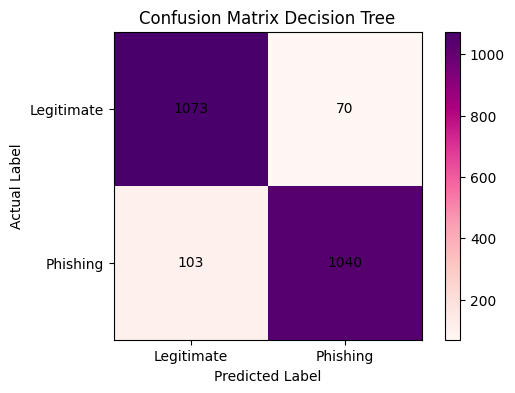

In [51]:
plt.figure(figsize=(6, 4))
plt.imshow(cm_dt, cmap="RdPu")

plt.title("Confusion Matrix Decision Tree")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.yticks([0, 1], ["Legitimate", "Phishing"])

for i in range(cm_dt.shape[0]):
    for j in range(cm_dt.shape[1]):
        plt.text(
            j,
            i,
            cm_dt[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar()
plt.show()

Classification report menampilkan evaluasi model secara lebih lengkap untuk setiap kelas. Nilai precision, recall, dan F1 score digunakan untuk melihat kemampuan model dalam mengenali website legitimate dan phishing.

In [52]:
print("Classification Report Decision Tree:")
print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["Legitimate", "Phishing"]
))

Classification Report Decision Tree:
              precision    recall  f1-score   support

  Legitimate       0.91      0.94      0.93      1143
    Phishing       0.94      0.91      0.92      1143

    accuracy                           0.92      2286
   macro avg       0.92      0.92      0.92      2286
weighted avg       0.92      0.92      0.92      2286



Model XGBoost digunakan sebagai pembanding dari Decision Tree. Model ini menjadi bagian eksplorasi tambahan karena belum dipelajari di kelas dan dapat meningkatkan performa klasifikasi.

In [53]:
xgboost_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42,
    eval_metric="logloss"
)

xgboost_model.fit(X_train, y_train)

print("Model XGBoost berhasil dilatih.")

Model XGBoost berhasil dilatih.


Model XGBoost yang sudah dilatih digunakan untuk memprediksi data testing. Hasil prediksi ini akan dibandingkan dengan label asli untuk menilai performa model.

In [54]:
y_pred_xgb = xgboost_model.predict(X_test)

print("Hasil prediksi XGBoost:")
print(y_pred_xgb[:10])

print("\nLabel asli:")
print(y_test.values[:10])

Hasil prediksi XGBoost:
[1 1 1 1 0 0 0 1 0 1]

Label asli:
[1 1 1 1 0 0 0 1 0 1]


Evaluasi XGBoost dilakukan untuk mengetahui kemampuan model dalam mengklasifikasikan website legitimate dan phishing. Metrik yang digunakan sama seperti Decision Tree agar hasil kedua model dapat dibandingkan secara adil.

In [55]:
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("Evaluasi Model XGBoost")
print("Accuracy :", round(accuracy_xgb, 4))
print("Precision:", round(precision_xgb, 4))
print("Recall   :", round(recall_xgb, 4))
print("F1 Score :", round(f1_xgb, 4))

Evaluasi Model XGBoost
Accuracy : 0.9602
Precision: 0.9582
Recall   : 0.9624
F1 Score : 0.9603


Confusion matrix digunakan untuk melihat rincian prediksi XGBoost pada kelas legitimate dan phishing. Hasil ini membantu mengetahui jumlah prediksi yang benar dan salah pada masing-masing kelas.

In [56]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

print("Confusion Matrix XGBoost:")
print(cm_xgb)

Confusion Matrix XGBoost:
[[1095   48]
 [  43 1100]]


Visualisasi confusion matrix XGBoost membantu menampilkan hasil klasifikasi secara lebih jelas. Baris menunjukkan label asli, sedangkan kolom menunjukkan hasil prediksi model.

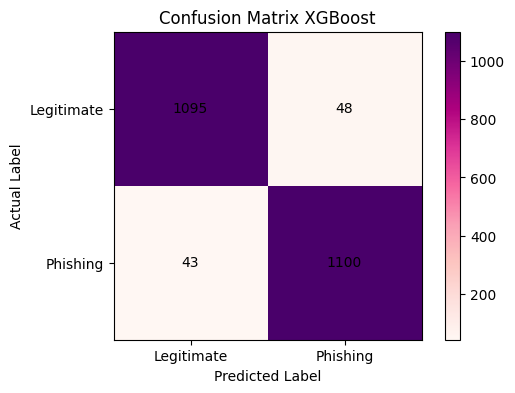

In [57]:
plt.figure(figsize=(6, 4))
plt.imshow(cm_xgb, cmap="RdPu")

plt.title("Confusion Matrix XGBoost")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Legitimate", "Phishing"])
plt.yticks([0, 1], ["Legitimate", "Phishing"])

for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        plt.text(
            j,
            i,
            cm_xgb[i, j],
            ha="center",
            va="center",
            color="black"
        )

plt.colorbar()
plt.show()

Classification report XGBoost menampilkan hasil evaluasi lebih lengkap pada setiap kelas. Nilai precision, recall, dan F1 score digunakan untuk melihat seberapa baik model mengenali website legitimate dan phishing.

In [58]:
print("Classification Report XGBoost:")
print(classification_report(
    y_test,
    y_pred_xgb,
    target_names=["Legitimate", "Phishing"]
))

Classification Report XGBoost:
              precision    recall  f1-score   support

  Legitimate       0.96      0.96      0.96      1143
    Phishing       0.96      0.96      0.96      1143

    accuracy                           0.96      2286
   macro avg       0.96      0.96      0.96      2286
weighted avg       0.96      0.96      0.96      2286



Tabel ini digunakan untuk membandingkan performa Decision Tree dan XGBoost. Perbandingan dilakukan berdasarkan accuracy, precision, recall, dan F1 score.

In [59]:
model_comparison = pd.DataFrame({
    "Model": ["Decision Tree", "XGBoost"],
    "Accuracy": [accuracy_dt, accuracy_xgb],
    "Precision": [precision_dt, precision_xgb],
    "Recall": [recall_dt, recall_xgb],
    "F1 Score": [f1_dt, f1_xgb]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.924322,0.936937,0.909886,0.923213
1,XGBoost,0.960192,0.958188,0.962380,0.960279


Grafik ini menampilkan perbandingan performa Decision Tree dan XGBoost berdasarkan accuracy, precision, recall, dan F1 score. Visualisasi ini membantu menentukan model mana yang memiliki hasil terbaik.

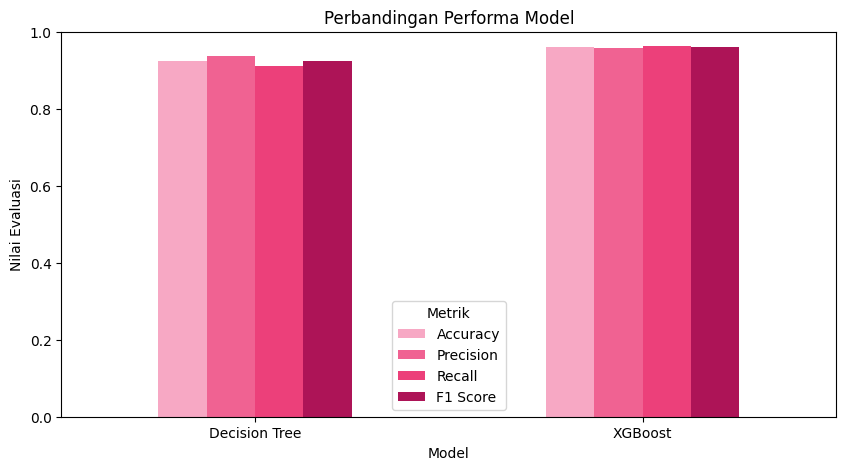

In [60]:
model_comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10, 5),
    color=["#f7a8c4", "#f06292", "#ec407a", "#ad1457"]
)

plt.title("Perbandingan Performa Model")
plt.xlabel("Model")
plt.ylabel("Nilai Evaluasi")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metrik")
plt.show()

Model terbaik dipilih berdasarkan nilai F1 Score tertinggi. F1 Score digunakan karena metrik ini menyeimbangkan precision dan recall, sehingga cocok untuk kasus deteksi phishing.

In [61]:
best_model_row = model_comparison.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]

best_model_name = best_model_row["Model"]

if best_model_name == "Decision Tree":
    best_model = decision_tree
else:
    best_model = xgboost_model

print("Model terbaik:", best_model_name)
print("F1 Score terbaik:", round(best_model_row["F1 Score"], 4))

Model terbaik: XGBoost
F1 Score terbaik: 0.9603


Feature importance digunakan untuk melihat fitur URL yang paling berpengaruh dalam proses klasifikasi. Hasil ini membantu menjelaskan alasan model dalam membedakan website legitimate dan phishing.

In [62]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
85,google_index,0.561413
56,nb_hyperlinks,0.035412
6,nb_qm,0.031274
86,page_rank,0.029547
20,nb_www,0.023005
26,ratio_digits_host,0.019803
2,ip,0.018227
50,phish_hints,0.015007
54,suspecious_tld,0.013792
39,length_words_raw,0.011069


Grafik ini menampilkan sepuluh fitur paling berpengaruh pada model terbaik. Semakin besar nilai importance, semakin besar peran fitur tersebut dalam proses prediksi.

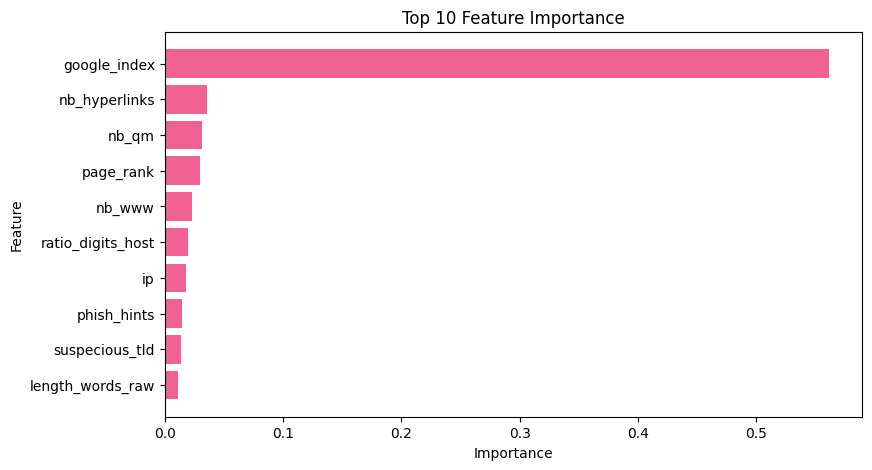

In [63]:
top_features = feature_importance.head(10)

plt.figure(figsize=(9, 5))
plt.barh(
    top_features["Feature"],
    top_features["Importance"],
    color="#f06292"
)

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.show()

Model terbaik disimpan dalam format pickle agar dapat digunakan kembali pada tahap deployment. Daftar fitur juga disimpan supaya urutan input pada aplikasi tetap sesuai dengan data training.

In [64]:
with open("best_phishing_model.pkl", "wb") as file:
    pickle.dump(best_model, file)

with open("feature_names.pkl", "wb") as file:
    pickle.dump(list(X.columns), file)

print("Model berhasil disimpan sebagai best_phishing_model.pkl")
print("Daftar fitur berhasil disimpan sebagai feature_names.pkl")

Model berhasil disimpan sebagai best_phishing_model.pkl
Daftar fitur berhasil disimpan sebagai feature_names.pkl
